# Kunskapskontroll 1 

## 1. Inledning och kontext

Detta dataset representerar en simulering och statististisk sammaställning av de 48 landslag som förväntas delta i **FIFA World Cup 2026**

**Om datan:**
- **Källor:** Det används två dataset från Kaggle: 
    - FIFA World Cup Team Dataset, här har jag sparat två filer: fifa_history (som är historisk statistik från tidigare vm ) samt fifa_2026 (som är statisitk simulering av de 48 lagen inför vm 2026)
    - Football Transfer Market Dataset, här har jag sparat två filer: players (spelare från hela världen ) samt transfermarkt ( övergångar över alla ligor)
- **Population:** Varje rad representerar ett specifikt landslag, spelare eller transfer. 
- **Variabler:** Datasetet innehåller 24 kolumner med allt från historiska meriter (tidigare titlar) till nuvarande form (mål och vinster de senaste 4 åren)
- **Syfte:** Att undersöka faktorer som påverkar ett lags förväntade framgång inför det utökade VM-formatet. Samt kunna se lagens värde gentemot prestation och hur det har gått för värdnationerna. 
- **Begränsningar:* Datasetet för historik sträcker sig från 2002 till 2022, vilket innebär att äldre historiska prestationer (som Frankrikes guld 1998) inte inkluderas i analysen.
Eftersom jag slår ihop två dataset där vi har historisk data och framtida data. 
Detta gör att viss data kommer inte att finnas till exempel på winner för 2026. 
jag väljer att radera dessa tomma rader automatiskt. Detta för att inte medvetet blanda ihop faktiska resultat med framtidsprogrnoser utifrån missvisande sätt.  



In [43]:
!pip install pandas numpy matplotlib seaborn 

# importera de olika paketen. Vi använder oss av matplotlib och seabord för att skapa visuella diagram
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Inmatning och verifiering av data 

### hämta in dataseten som jag ska arbeta med och se hur stora de är

In [44]:
# Ladda in alla dataseten som vi arbetar med
df_history = pd.read_csv("data/fifa_history.csv")
df_2026 = pd.read_csv("data/fifa_2026.csv")
df_players = pd.read_csv(f"data/players.csv")
df_market = pd.read_csv(f"data/transfermarkt.csv")

# Inspektera historisk data för tidigare vm
print("history table")
print(f"Historik (Train): {df_history.shape[0]} rader, {df_history.shape[1]} kolumner")
display(df_history.head(3))

print(" ")

# Inspektera framtida data
print("wc 2026 table")
print(f"VM 2026 (Test): {df_2026.shape[0]} rader, {df_2026.shape[1]} kolumner")
display(df_2026.head(3))

print(" ")

# Inspektera spelardata
print("players table")
print(f"Spelardata: {df_players.shape[0]} rader, {df_players.shape[1]} kolumner")
display(df_players.head(3))

print(" ")

# Inspektera marknadsvärdesdata
print("transfermarkt table")
print(f"Marknadsvärde: {df_market.shape[0]} rader, {df_market.shape[1]} kolumner")
display(df_market.head(3))

history table
Historik (Train): 192 rader, 24 kolumner


,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2006,Angola,Africa,0,61,49,19,13,14,0,52700000.0,57,581.0,29.2,0,0,0,0,0,0,0,0,0,0
1,2006,Argentina,South America,0,97,55,31,10,10,2,777200000.0,9,746.0,27.8,13,10,5,6,4,4,0,0,0,1
2,2006,Australia,Oceania,0,101,34,23,8,5,0,48030000.0,42,612.0,27.1,1,0,0,0,0,0,0,0,0,0


 
wc 2026 table
VM 2026 (Test): 48 rader, 24 kolumner


,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2026,France,Europe,0,85,32,25,6,7,2,1290000000,1,1877.32,26.7,16,10,8,9,7,4,NaN,NaN,NaN,NaN
1,2026,Spain,Europe,0,104,32,29,2,8,1,1150000000,2,1876.40,27.2,16,11,9,6,2,1,NaN,NaN,NaN,NaN
2,2026,Argentina,South America,0,80,14,30,4,3,3,575000000,3,1874.81,27.9,18,15,10,10,6,6,NaN,NaN,NaN,NaN


 
players table
Spelardata: 1975 rader, 8 kolumner


,PlayerName,Post,Age,MarketValue,Nationality,Left,Current_team,Fee
0,Kylian Mbappé,Centre-Forward,25,180.00m,France,Paris Saint-Germain,Real Madrid,free transfer
1,Victor Osimhen,Centre-Forward,25,100.00m,Nigeria,SSC Napoli,Galatasaray,loan transfer
2,Julián Alvarez,Centre-Forward,24,90.00m,Argentina,Manchester City,Atlético de Madrid,75.00m


 
transfermarkt table
Marknadsvärde: 1475 rader, 10 kolumner


,Name,Age,Position,Player Nationality,Market Value,Left,LeagueLefted,Joined,LeagueJoined,Fee
0,Kylian Mbappé,25,Centre-Forward,France,180.0,Paris SG,Ligue 1,Real Madrid,LaLiga,NaN
1,Victor Osimhen,25,Centre-Forward,Nigeria,100.0,Napoli,Serie A,Galatasaray,Süper Lig,NaN
2,Julián Alvarez,24,Centre-Forward,Argentina,90.0,Man City,Premier League,Atlético Madrid,LaLiga,75.0


### Sammanslagningen
här slår vi ihop historiska och framtida dataseten till en. 
att kunna arbeta med en gemensamm dataset för både framtida och historisk data för lagen. 
Vi har fortfrande spelarna och transfer dataseten

In [46]:
# 1. Ge dem en "etikett" så vi vet vad som är vad sen
df_history["status"] = "Historik"
df_2026["status"] = "2026"
df_market[""] = "market"
df_players["afla"] = "player"
# 2. Slå ihop dem
# ignore_index=True gör att vi får en ny snygg numrering från 0 till slutet
df = pd.concat([df_history, df_2026], ignore_index=True)

dff = pd.concat([df_market, df_players], ignore_index=True)
display(dff)

# 3. Kontrollera resultatet
print(
    f"Nu har vi slagit ihpa de två dataseten och då får vi totalt antal rader: {df.shape[0]}"
)

print(" ")
print(" här ser vi slutet av datasetet där data från prediktion är.")
display(df.tail())
df.isnull().sum()  # kollar antalet icke siffer värden

,Name,Age,Position,Player Nationality,Market Value,Left,LeagueLefted,Joined,LeagueJoined,Fee,,PlayerName,Post,MarketValue,Nationality,Current_team,afla
0,Kylian Mbappé,25,Centre-Forward,France,180.0,Paris SG,Ligue 1,Real Madrid,LaLiga,NaN,market,NaN,NaN,NaN,NaN,NaN,NaN
1,Victor Osimhen,25,Centre-Forward,Nigeria,100.0,Napoli,Serie A,Galatasaray,Süper Lig,NaN,market,NaN,NaN,NaN,NaN,NaN,NaN
2,Julián Alvarez,24,Centre-Forward,Argentina,90.0,Man City,Premier League,Atlético Madrid,LaLiga,75.0,market,NaN,NaN,NaN,NaN,NaN,NaN
3,Khvicha Kvaratskhelia,23,Left Winger,Georgia,85.0,Napoli,Serie A,Paris SG,Ligue 1,70.0,market,NaN,NaN,NaN,NaN,NaN,NaN
4,Xavi Simons,21,Attacking Midfield,Netherlands,80.0,Paris SG,Ligue 1,RB Leipzig,Bundesliga,50.0,market,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3445,NaN,26,NaN,NaN,NaN,Middlesbrough FC,NaN,NaN,NaN,loan transfer,NaN,Lukas Engel,Left-Back,2.20m,Denmark,FC Cincinnati,player
3446,NaN,24,NaN,NaN,NaN,SK Slavia Prague,NaN,NaN,NaN,loan transfer,NaN,Conrad Wallem,Right Midfield,2.20m,Norway,St. Louis CITY SC,player
3447,NaN,21,NaN,NaN,NaN,Deportivo Cali,NaN,NaN,NaN,0,NaN,Juan Córdoba,Right Winger,1.20m,Colombia,GNK Dinamo Zagreb,player
3448,NaN,28,NaN,NaN,NaN,Adana Demirspor,NaN,NaN,NaN,free transfer,NaN,Dorukhan Toköz,Central Midfield,2.10m,Türkiye,Eyüpspor,player


Nu har vi slagit ihpa de två dataseten och då får vi totalt antal rader: 240
 
 här ser vi slutet av datasetet där data från prediktion är.


,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist,status
235,2026,Cape Verde,Africa,0,46,39,16,10,12,0,31830000.0,69,1366.13,29.2,0,0,0,0,0,0,NaN,NaN,NaN,NaN,2026
236,2026,Ghana,Africa,0,46,42,12,13,9,0,164900000.0,74,1346.31,25.1,4,2,2,1,0,0,NaN,NaN,NaN,NaN,2026
237,2026,Cura?o,North America,0,55,39,12,10,10,0,25380000.0,82,1294.65,26.5,0,0,0,0,0,0,NaN,NaN,NaN,NaN,2026
238,2026,Haiti,North America,0,71,37,16,8,8,0,38750000.0,83,1291.71,27.6,1,0,0,0,0,0,NaN,NaN,NaN,NaN,2026
239,2026,New Zealand,Oceania,0,63,32,13,12,6,0,16430000.0,85,1281.57,27.8,2,0,0,0,0,0,NaN,NaN,NaN,NaN,2026


version                             0
team                                0
continent                           0
is_host                             0
goals_scored_last_4y                0
goals_received_last_4y              0
wins_last_4y                        0
losses_last_4y                      0
draws_last_4y                       0
world_cup_titles_before             0
squad_total_market_value_eur       32
fifa_rank_pre_tournament            0
fifa_points_pre_tournament          0
squad_avg_age                       0
world_cup_participations_before     0
groups_passed_before                0
round16_before                      0
quarterfinals_before                0
semifinals_before                   0
finals_before                       0
winner                             48
finalist                           48
semi_finalist                      48
quarter_finalist                   48
status                              0
dtype: int64

### data integration : 
aggregering av spelarvärden och skapa en enhetlig dataset

In [ ]:
# 1. En funktion som fattar skillnaden på 'm' och 'k'
def clean_market_value(val):
    if pd.isna(val) or val == "":
        return 0.0

    val = str(val).lower().replace("€", "").strip()

    if "m" in val:
        # '180.00m' -> 180.0
        return float(val.replace("m", ""))
    elif "k" in val:
        # '800k' -> 0.8 (vi gör om tusen till miljoner för att matcha)
        return float(val.replace("k", "")) / 1000

    try:
        return float(val)
    except:
        return 0.0


# 2. Kör funktionen på MarketValue
df_players["MarketValue"] = df_players["MarketValue"].apply(clean_market_value)

# 3. Gruppering
df_economy = (
    df_players.groupby("Nationality")
    .agg(
        {
            "MarketValue": "sum",
            "Age": "mean",
            "PlayerName": "count",
        }
    )
    .reset_index()
)

# 4. sparar en kopia som vi döper med
df_economy.columns = ["team_name", "total_market_value", "avg_age", "squad_size"]
df_before_merge = df.copy()

# 5. Merge
df_final = pd.merge(df, df_economy, left_on="team", right_on="team_name", how="left")

# 6. Fyll 0 för de som saknas
df_final["total_market_value"] = df_final["total_market_value"].fillna(0)


## 3. Datatvätt 
ta bort data(NaN) som vi inte behöver och som vi inte vill hantera för att inte få felaktiga resultat

Efter sammanslagningen ser vi att kolumnerna winner, finalist, semi_finalist och quarter_finalist har många saknade värden.

Motivering: Dessa NaN beror inte på felaktig datainsamling, utan på att 2026-turneringen ännu inte har spelats. För att kunna använda dessa kolumner i numeriska analyser väljer jag att imputera (fylla) dessa värden med 0. Detta representerar att lagen i projektionen för 2026 än så länge har noll vinster eller finalplatser i det kommande mästerskapet.

In [48]:
# Lista på de kolumner som rör slutplaceringar
cols_to_fix = ["winner", "finalist", "semi_finalist", "quarter_finalist"]

# Fyll alla NaN i dessa kolumner med 0
df[cols_to_fix] = df[cols_to_fix].fillna(0)

# Verifiera att de saknade värdena är borta i just dessa kolumner
print("Antal saknade värden efter tvätt:")
print(df[cols_to_fix].isnull().sum())

Antal saknade värden efter tvätt:
winner              0
finalist            0
semi_finalist       0
quarter_finalist    0
dtype: int64


## datatyper

Här vill vi verifiera så att de olika kolumnerna har rätt datatyper. Detta är för att vi ska kunna arbeta med dem på rätt sätt. 
Här listar jag alla kolumneran och här ser vi också att det inte finns några objekt. det hade medfört problem när vi ska räkna ut medelvärden eller skapa grafer

In [49]:
# Kolla vilka typer kolumnerna har
print(df.dtypes)

version                              int64
team                                   str
continent                              str
is_host                              int64
goals_scored_last_4y                 int64
goals_received_last_4y               int64
wins_last_4y                         int64
losses_last_4y                       int64
draws_last_4y                        int64
world_cup_titles_before              int64
squad_total_market_value_eur       float64
fifa_rank_pre_tournament             int64
fifa_points_pre_tournament         float64
squad_avg_age                      float64
world_cup_participations_before      int64
groups_passed_before                 int64
round16_before                       int64
quarterfinals_before                 int64
semifinals_before                    int64
finals_before                        int64
winner                             float64
finalist                           float64
semi_finalist                      float64
quarter_fin

## 4. Datainhämtning & Visualisering

### 1. De ekonomiska jättarna och pöbeln 

Vilka landslag har stora ekonomiska muskler efter det totala marknadsvärdet. Utgår ufrån VM 2026? 

vi börjar med att sortera ut de 10 dyraste lagen utifrån marknads värdet och skriver ut det så att vi kan verifiera så att datan ser ok ut.


vi börjar med att hämta datan för att kunna visualisera vilka de 10 landslagen med dyraste spelarna. 
Här kan vi också titta på andra sidan där vi tittar på de 10 lagen som har minst värdefulla spelarna. 

In [50]:
# vi tar fram data utifrån spelarnas dataframe och grupperar dem utifrån nationalitet och marknadsvärde
team_value_data = df_players.groupby("Nationality")["MarketValue"].sum().reset_index()

# Sedan så kan vi döpa om kolumneran för att göra dem lättare att förstå
team_value_data.columns = ["Landslag", "Totalt marknadsvärde (M€)"]

# tänkte mig att använda ett stapeldiagram för att visualsiera detta och då blir det mer lättläst om vi sorterar dem utifrån z-a
team_value_data = team_value_data.sort_values(
    by="Totalt marknadsvärde (M€)", ascending=False
)

# göra en kopia av den datan ovanför för att kunna arbeta med denna men samtidigt ha kvar data i orginal skick
most_expensive_top_10_nation_teams = team_value_data.head(10).reset_index(drop=True)

# jag skapade en för de 10 som ligger i botten med
least_expensive_top_10_nations_teams = team_value_data.tail(10).reset_index(drop=True)


print("Data redo för analys av ekonomiska jättar:")
display(most_expensive_top_10_nation_teams)


print("Data redo för analys av de inte ekonomiska jättarna :")
display(least_expensive_top_10_nations_teams)


# skapa en variabel med de 10 mest exensiva lagen
top_10_expensive = df_final[df_final["status"] == "2026"].nlargest(
    10, "total_market_value"
)

# och då hmtar vi också de 10 minst värdefulla lagen med
top_10_least_expensive = df_final[df_final["status"] == "2026"].nsmallest(
    10, "total_market_value"
)


df_clean_top_10 = top_10_expensive.reset_index(drop=True)
df_clean_bootm_10 = top_10_least_expensive.reset_index(drop=True)
print(df_clean_top_10)
print(df_clean_bootm_10)

Data redo för analys av ekonomiska jättar:


,Landslag,Totalt marknadsvärde (M€)
0,France,1452.4
1,Brazil,1359.2
2,England,1268.1
3,Spain,904.5
4,Argentina,861.8
5,Italy,669.6
6,Portugal,645.4
7,Netherlands,628.4
8,Belgium,508.1
9,Germany,448.8


Data redo för analys av de inte ekonomiska jättarna :


,Landslag,Totalt marknadsvärde (M€)
0,Dominican Republic,3.000
1,Bahrain,2.500
2,Belarus,2.500
3,Iraq,2.500
4,Cyprus,2.500
5,Grenada,2.500
6,Martinique,2.500
7,Guadeloupe,1.500
8,Sierra Leone,1.000
9,Costa Rica,0.175


   version         team      continent  is_host  goals_scored_last_4y  goals_received_last_4y  wins_last_4y  losses_last_4y  draws_last_4y  world_cup_titles_before  squad_total_market_value_eur  fifa_rank_pre_tournament  fifa_points_pre_tournament  squad_avg_age  world_cup_participations_before  groups_passed_before  round16_before  quarterfinals_before  semifinals_before  finals_before  winner  finalist  semi_finalist  quarter_finalist status    team_name  total_market_value    avg_age  squad_size
0     2026       France         Europe        0                    85                      32            25               6              7                        2                  1.290000e+09                         1                     1877.32           26.7                               16                    10               8                     9                  7              4     NaN       NaN            NaN               NaN   2026       France              1452.4  23.965517     

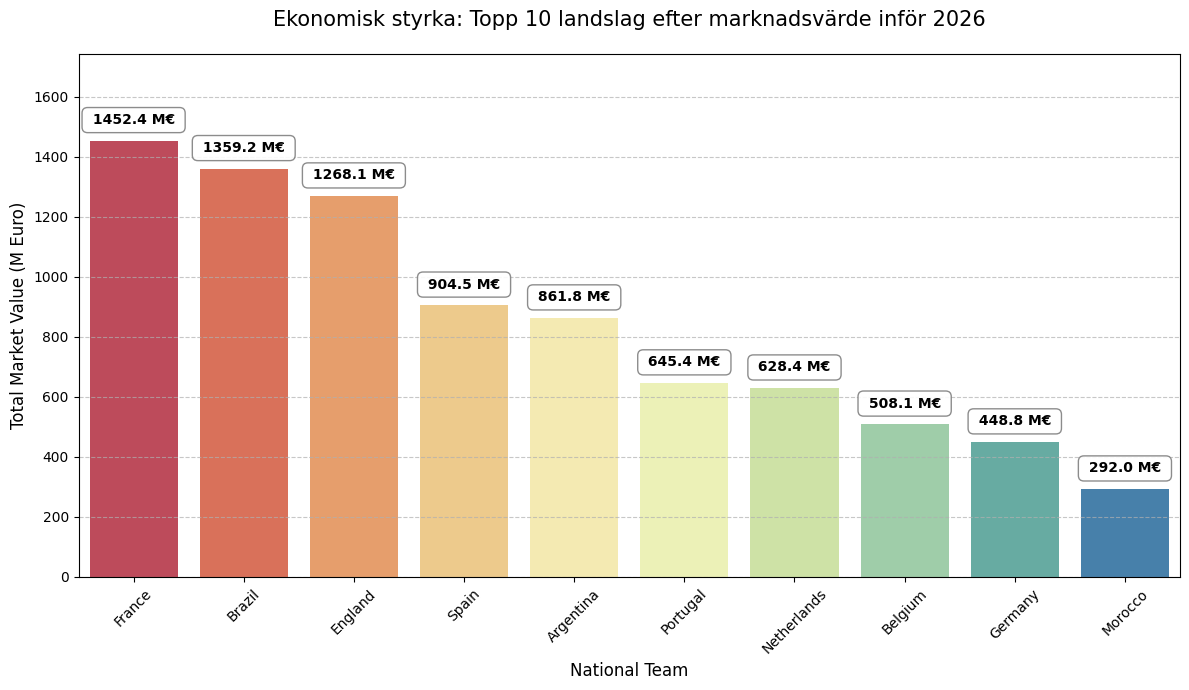

In [62]:
plt.figure(figsize=(12, 7))  

# Skapa ax-objektet för att kunna lägga till annoteringar
ax = sns.barplot(
    data=top_10_expensive,
    x="team",
    y="total_market_value",
    palette="Spectral",
    hue="team",
    legend=False,
)

# 1. Öka marginalen uppåt för att ge plats åt boxarna
max_val = top_10_expensive["total_market_value"].max()
plt.ylim(0, max_val * 1.2)

# 2. Lägg till värden ovanför varje stapel
for i, p in enumerate(ax.patches):
    value = p.get_height()  # Hämtar höjden på stapeln (marknadsvärdet)

    # Vi lägger till en decimal (.1f) eftersom det är pengar
    ax.annotate(
        f" {value:.1f} M€ ",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 10),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", lw=1, alpha=0.9),
    )

plt.title(
    "Ekonomisk styrka: Topp 10 landslag efter marknadsvärde inför 2026",
    fontsize=15,
    pad=20,
)
plt.xlabel("National Team", fontsize=12)
plt.ylabel("Total Market Value (M Euro)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Ålderns ytterlighet

Vad kan vi säga utifrån truppens balans genom att se vilka tre spelare som är yngst och äldst gentemot alla landslag

In [67]:
oldest_player = df_players.nlargest(3, "Age")[["PlayerName", "Nationality", "Age"]]
youngest_players = df_players.nsmallest(3, "Age")[["PlayerName", "Nationality", "Age"]]

# merga ihopa dessa två dataseten
dataframe_age_old_young = pd.concat([oldest_player, youngest_players])

# addera en kolumn för att vi ska kunna hantera visualisering. Vi adderar färgkodning eller kategori.
dataframe_age_old_young["Kategory"] = [
    "Veteran",
    "Veteran",
    "Veteran",
    "Talang",
    "Talang",
    "Talang",
]

print("Data för åldersanalys redo:")
df_clean = dataframe_age_old_young.reset_index(drop=True)

display(df_clean)

median_age = df_players["Age"].median()

print(f"Medianåldern för samtliga spelare är: {median_age} år")

Data för åldersanalys redo:


,PlayerName,Nationality,Age,Kategory
0,Olivier Giroud,France,37,Veteran
1,Ivan Rakitic,Croatia,36,Veteran
2,Willian,Brazil,36,Veteran
3,Alvin Ayman,England,16,Talang
4,George Ilenikhena,Nigeria,17,Talang
5,Joane Gadou,France,17,Talang


Medianåldern för samtliga spelare är: 24.0 år


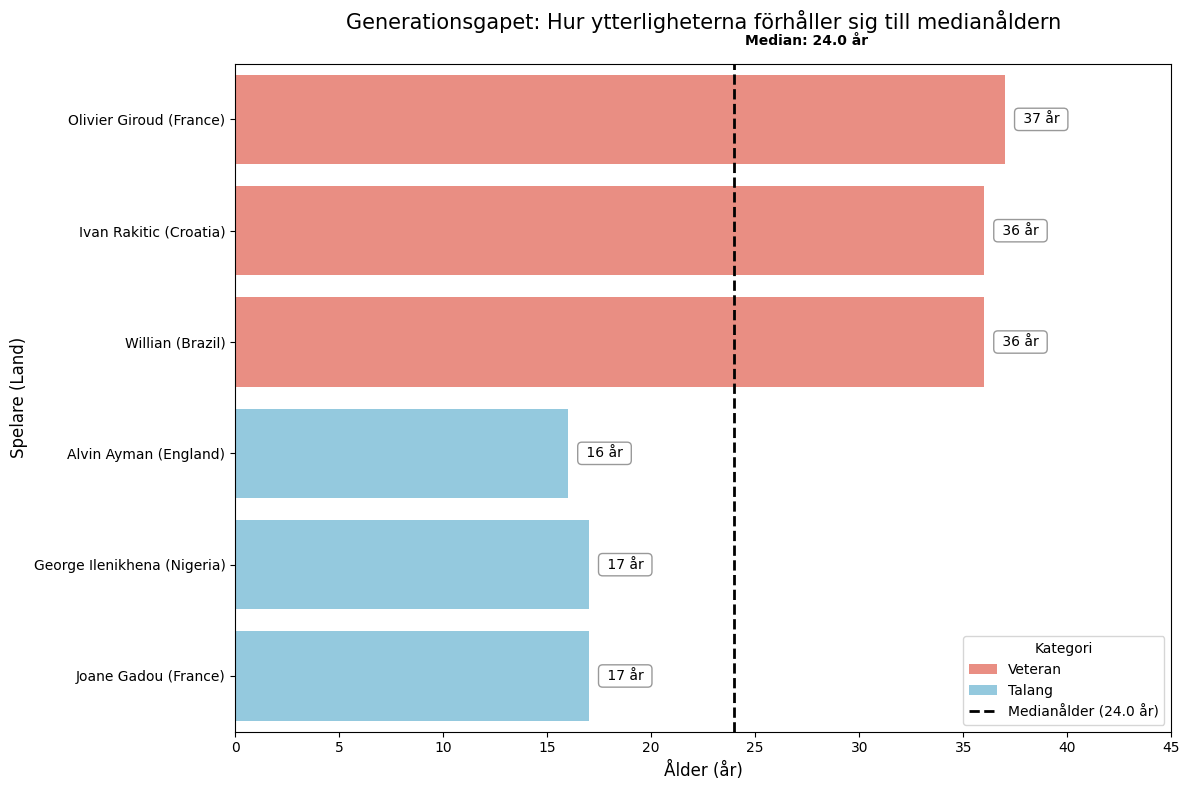

In [ ]:
# 1. Beräkna medianen från det stora datasetet (df_players)
# Detta steg är viktigt för att få rätt referenspunkt
median_age = df_players["Age"].median()

# 2. Skapa den kombinerade kolumnen
df_clean["Player_With_Country"] = (
    df_clean["PlayerName"] + " (" + df_clean["Nationality"] + ")"
)

plt.figure(figsize=(12, 8))

# 3. Rita stapeldiagrammet
ax = sns.barplot(
    data=df_clean,
    x="Age",
    y="Player_With_Country",
    hue="Kategory",
    palette={"Veteran": "salmon", "Talang": "skyblue"},
)

# --- NYTT: Lägg till medianlinjen ---
plt.axvline(
    x=median_age,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Medianålder ({median_age} år)",
)

# Lägg till en textetikett för medianlinjen
plt.text(
    median_age + 0.5,
    -0.7,
    f"Median: {median_age} år",
    color="black",
    fontweight="bold",
    va="center",
)

# Annoteringar (åldersboxarna )
for i, p in enumerate(ax.patches):
    if p.get_width() > 0:
        ax.annotate(
            f" {int(p.get_width())} år ",
            (p.get_width(), p.get_y() + p.get_height() / 2),
            va="center",
            xytext=(10, 0),
            textcoords="offset points",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
        )

# Styling och titlar
plt.title(
    "Generationsgapet: Hur ytterligheterna förhåller sig till medianåldern",
    fontsize=15,
    pad=25,
)
plt.xlabel("Ålder (år)", fontsize=12)
plt.ylabel("Spelare (Land)", fontsize=12)

# Sätt x-axeln till 45 för att skapa utrymme och röd tråd
plt.xlim(0, 45)

plt.legend(title="Kategori", loc="lower right")
plt.tight_layout()
plt.show()

### 3. Ligornas makt

här kan man se vilken liga i världen som "äger" flest spelare som spelar i landslagen

In [ ]:
# här behöver vi hämta information från både players datasetet och koppla dem till transfers datasetet. Så vi mergar ihopa dem så vi kan arbeta bätrre med dem
df_players = df_players.rename(columns={"Post": "Position"})
df_merge_player_leage = pd.merge(
    df_players,
    df_market[["Name", "LeagueJoined"]],
    left_on="PlayerName",
    right_on="Name",
    how="left",
)


# nu har vi mergat dessa så då behöver vi tvätta lite data från dem eftersom där finns värden som kan vara saknade.
df_merge_player_leage["LeagueJoined"] = df_merge_player_leage["LeagueJoined"].fillna(
    "Ingen data"
)

# vi behöver inte kolumnen name från market df så vi tar bort den
df_merge_player_leage = df_merge_player_leage.drop(columns=["Name"])

# nu behöver vi räkna antalet spelare per liga
player_in_leage_count = (
    df_merge_player_leage.groupby("LeagueJoined")["PlayerName"].count().reset_index()
)


# här tänkte jag att jag kan döpa om kolumnernas namn så att det låter vettigare
player_in_leage_count.columns = ["Liga", "Antal spelare"]

top_10_leagues = player_in_leage_count.nlargest(10, "Antal spelare").reset_index(
    drop=True
)

print("De 10 ligorna med flest landslagsspelare:")
display(top_10_leagues)
#

De 10 ligorna med flest landslagsspelare:


,Liga,Antal spelare
0,Ingen data,473
1,Serie A,219
2,Premier League,201
3,Ligue 1,142
4,Bundesliga,140
5,Championship,127
6,LaLiga,125
7,Série A,105
8,Süper Lig,72
9,MLS,64


### Diagram för att visa de ligorna med flest landslagsseplare
här har jag valt att titta på bar diagrammet och ser positiva och negativa delar genom att titta på baren står horisontellt eller veritkalt

C:\Users\jarll\AppData\Local\Temp\ipykernel_52976\417305042.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


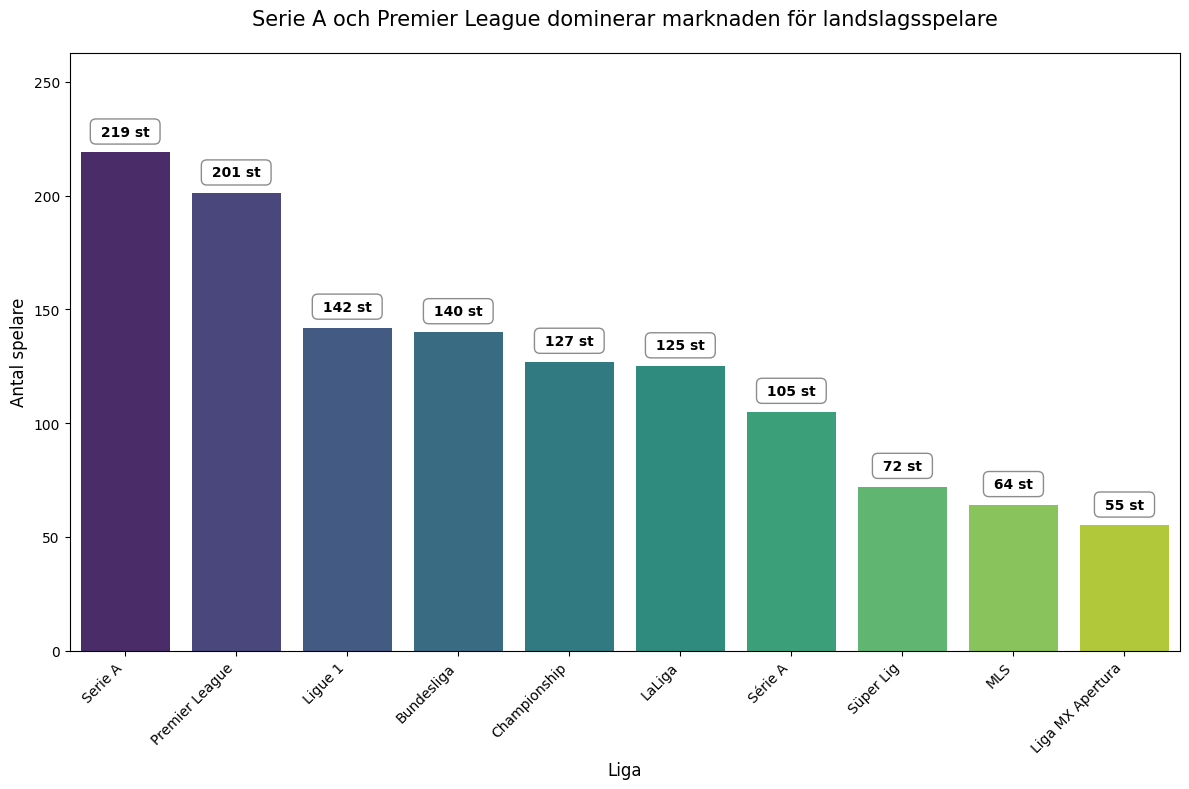

In [65]:
filtered_leagues_clean = player_in_leage_count[
    player_in_leage_count["Liga"] != "Ingen data"
].nlargest(10, "Antal spelare")

plt.figure(figsize=(12, 8))

# Vi byter plats: x = Liga, y = Antal spelare
ax = sns.barplot(
    data=filtered_leagues_clean, x="Liga", y="Antal spelare", palette="viridis"
)

# 1. Rotera liganamnen för att de inte ska krocka
plt.xticks(rotation=45, ha="right")

# 2. Öka marginalen i höjdled (y-axeln) för att ge plats åt boxarna ovanför
max_val = filtered_leagues_clean["Antal spelare"].max()
plt.ylim(0, max_val * 1.2)

# 3. Uppdaterad loop för lodrät positionering
for i, p in enumerate(ax.patches):
    value = int(p.get_height())  # Nu hämtar vi höjden istället för bredden

    ax.annotate(
        f" {value} st ",
        (p.get_x() + p.get_width() / 2, p.get_height()),  # Mitten av stapelns topp
        ha="center",  # Centrerat horisontellt över stapeln
        va="bottom",  # Placerat ovanför fästpunkten
        xytext=(0, 10),  # Flyttar upp boxen 10 punkter från toppen
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", lw=1, alpha=0.9),
    )

plt.title(
    "Serie A och Premier League dominerar marknaden för landslagsspelare",
    fontsize=15,
    pad=20,
)
plt.ylabel("Antal spelare", fontsize=12)
plt.xlabel("Liga", fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\jarll\AppData\Local\Temp\ipykernel_52976\4034921034.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


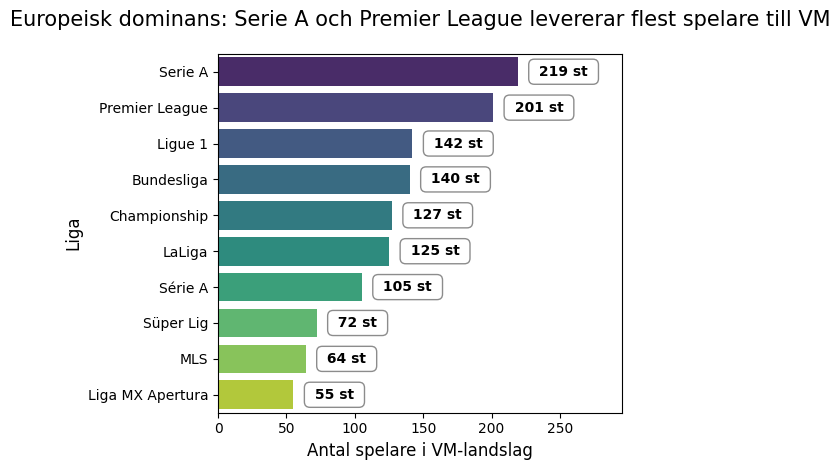

In [66]:

plt.Figure(figsize=(12, 8))

ax = sns.barplot(
    data=filtered_leagues_clean,
    x='Antal spelare',
    y='Liga',
    palette='viridis'
)

plt.title(
    "Europeisk dominans: Serie A och Premier League levererar flest spelare till VM",
    fontsize=15,
    pad=20,
)

plt.xlabel("Antal spelare i VM-landslag", fontsize=12)
plt.ylabel("Liga", fontsize=12)


for i, p in enumerate(ax.patches):
    value = int(p.get_width())

    # Genom att lägga till mellanslag ' {value} st ' blir boxen bredare
    ax.annotate(
        f" {value} st ",
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha="left",
        va="center",
        xytext=(12, 0),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.4",  # pad=0.4 ger lite mer luft runt om
            fc="white",
            ec="gray",
            lw=1,
            alpha=0.9,
        ),
    )

plt.tight_layout()
max_val = filtered_leagues_clean["Antal spelare"].max()
plt.xlim(0, max_val * 1.35)
plt.show()

C:\Users\jarll\AppData\Local\Temp\ipykernel_52976\4030668246.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_2026, x="continent", y="goals_scored_last_4y", palette="Set3")


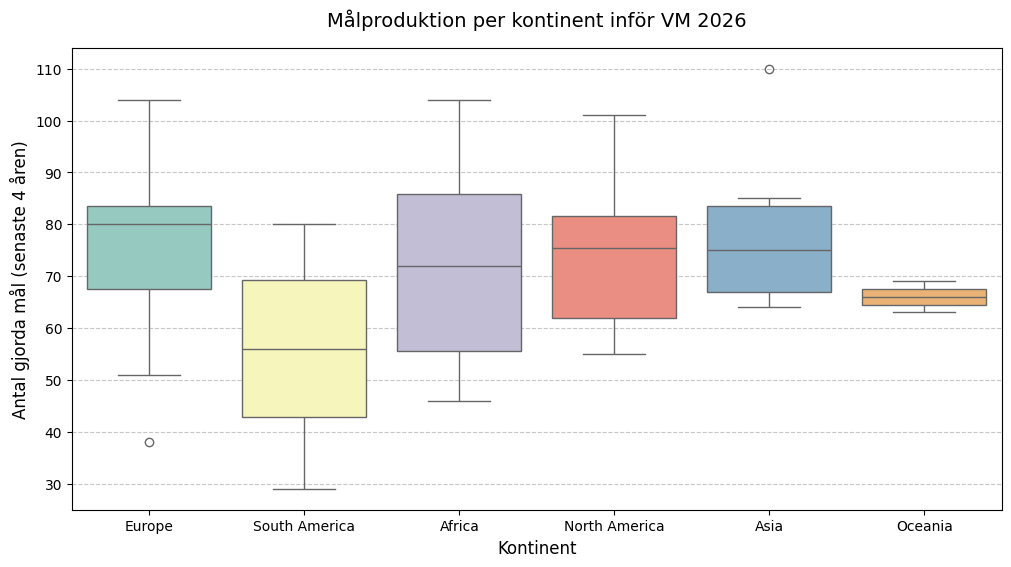

In [ ]:
plt.figure(figsize=(12, 6))

# Kontrollera att vi använder rätt kolumnnamn: goals_scored_last_4y
sns.boxplot(data=df_2026, x="continent", y="goals_scored_last_4y", palette="Set3")


plt.title("Målproduktion per kontinent inför VM 2026", fontsize=14, pad=15)
plt.xlabel("Kontinent", fontsize=12)
plt.ylabel("Antal gjorda mål (senaste 4 åren)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

### 4. Pengar vs Prestation 

kan  det finnas en korrelation mellan marknadsvinster och antal vinster under det senaste åren för landslagen? 


In [57]:
total_value_player_nation = (
    df_players.groupby("Nationality")["MarketValue"].sum().reset_index()
)
total_value_player_nation.columns = ["National Team", "Total_MarketValue_M€"]

df_performance = df_final[["team", "total_market_value", "wins_last_4y"]].copy()

df_performance.columns = [
    "National Team",
    "Marknadsvärde (M€)",
    "Vinster senaste 4 åren",
]

display(df_performance.head())

,National Team,Marknadsvärde (M€),Vinster senaste 4 åren
0,Angola,35.000,19
1,Argentina,861.800,31
2,Australia,22.500,23
3,Brazil,1359.200,30
4,Costa Rica,0.175,26


### Diagram för att visualisera korrleationen mellan marknadsvinsterna och antal vinster 

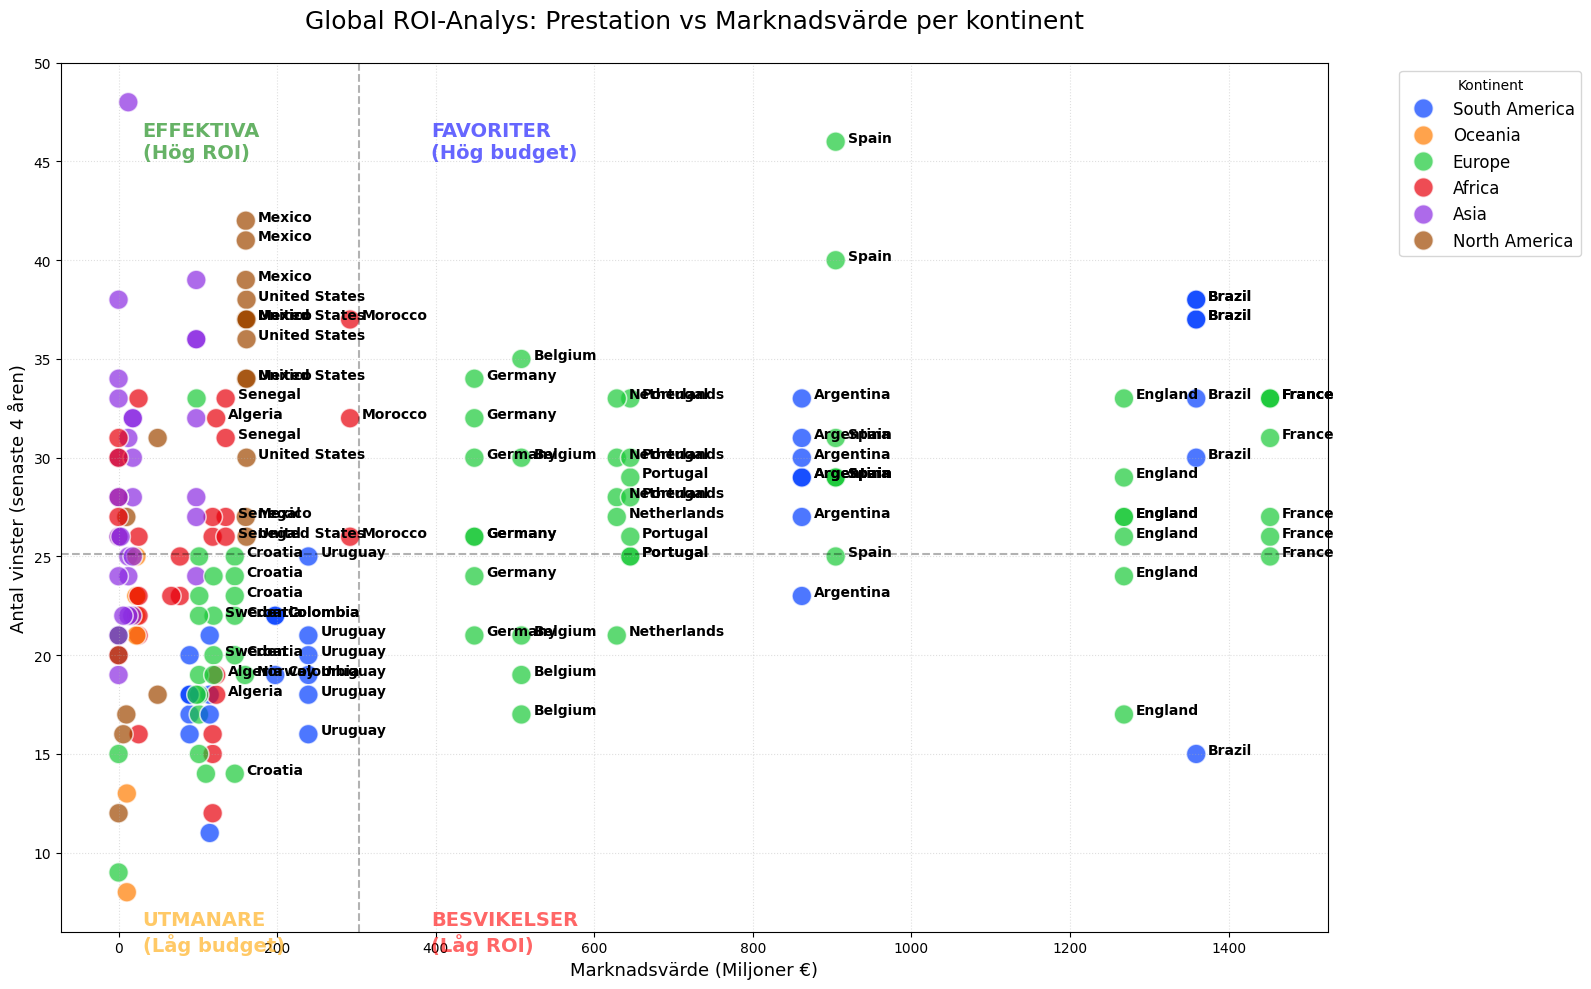

In [ ]:
plt.figure(figsize=(16, 10))

# 1. Förbered data (Sammanslagning)
df_perf_cont = df_performance.merge(
    df_2026[["team", "continent"]], left_on="National Team", right_on="team"
)

# 2. Beräkna medelvärden för linjerna
mean_val = df_performance["Marknadsvärde (M€)"].mean()
mean_wins = df_performance["Vinster senaste 4 åren"].mean()

# 3. Rita diagrammet med färg efter kontinent
ax = sns.scatterplot(
    data=df_perf_cont,
    x="Marknadsvärde (M€)",
    y="Vinster senaste 4 åren",
    hue="continent",  # Visar global fördelning
    s=200,
    alpha=0.7,
    palette="bright",
)

# 4. Lägg till kvadrant-linjerna
plt.axvline(mean_val, color="black", linestyle="--", alpha=0.3)
plt.axhline(mean_wins, color="black", linestyle="--", alpha=0.3)

# 5. Lägg till beskrivande text i varje kvadrant (ROI-zoner)
# Justera positionerna (0.1 och 1.1) baserat på datans skala om det behövs
plt.text(
    mean_val * 0.1,
    mean_wins * 1.8,
    "EFFEKTIVA\n(Hög ROI)",
    fontsize=14,
    fontweight="bold",
    color="green",
    alpha=0.6,
)

plt.text(
    mean_val * 1.3,
    mean_wins * 1.8,
    "FAVORITER\n(Hög budget)",
    fontsize=14,
    fontweight="bold",
    color="blue",
    alpha=0.6,
)

plt.text(
    mean_val * 0.1,
    mean_wins * 0.2,
    "UTMANARE\n(Låg budget)",
    fontsize=14,
    fontweight="bold",
    color="orange",
    alpha=0.6,
)

plt.text(
    mean_val * 1.3,
    mean_wins * 0.2,
    "BESVIKELSER\n(Låg ROI)",
    fontsize=14,
    fontweight="bold",
    color="red",
    alpha=0.6,
)



top_points = df_perf_cont.nlargest(100, "Marknadsvärde (M€)")
for i, row in top_points.iterrows():
    plt.text(
        row["Marknadsvärde (M€)"] + 15,
        row["Vinster senaste 4 åren"],
        row["National Team"],
        fontsize=10,
        fontweight="bold",
    )

# 7. Styling och Titel
plt.title(
    "Global ROI-Analys: Prestation vs Marknadsvärde per kontinent", fontsize=18, pad=25
)
plt.xlabel("Marknadsvärde (Miljoner €)", fontsize=13)
plt.ylabel("Antal vinster (senaste 4 åren)", fontsize=13)
plt.grid(True, linestyle=":", alpha=0.4)

# Flytta legenden utanför diagrammet
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Kontinent", fontsize=12)

plt.tight_layout()
plt.show()

### 5. Värdnationens fördel

Vilket värdland har vunnit flest matcher eller gått längs i hisitoriska VM

In [59]:
# vi behöver filtrera fram raderna från historisk data där lagen har varit värdnation
df_hosts_history = df_history[df_history["is_host"] == 1].copy()


# här kan det vara bra att kolla på totalt antal vinster samt antal vinster av hela vm.
host_success = (
    df_hosts_history.groupby("team")
    .agg(
        {
            "winner": "sum",
            "finalist": "sum",
            "semi_finalist": "sum",
            "quarter_finalist": "sum",
        }
    )
    .sort_values(by="winner", ascending=False)
)
print(host_success)

              winner  finalist  semi_finalist  quarter_finalist
team                                                           
Brazil             0         0              1                 1
Germany            0         0              1                 1
Japan              0         0              0                 0
Qatar              0         0              0                 0
Russia             0         0              0                 1
South Africa       0         0              0                 0
South Korea        0         0              1                 1


### Diagram för att visualisera hur det har gått för värnationerna sedan 2002

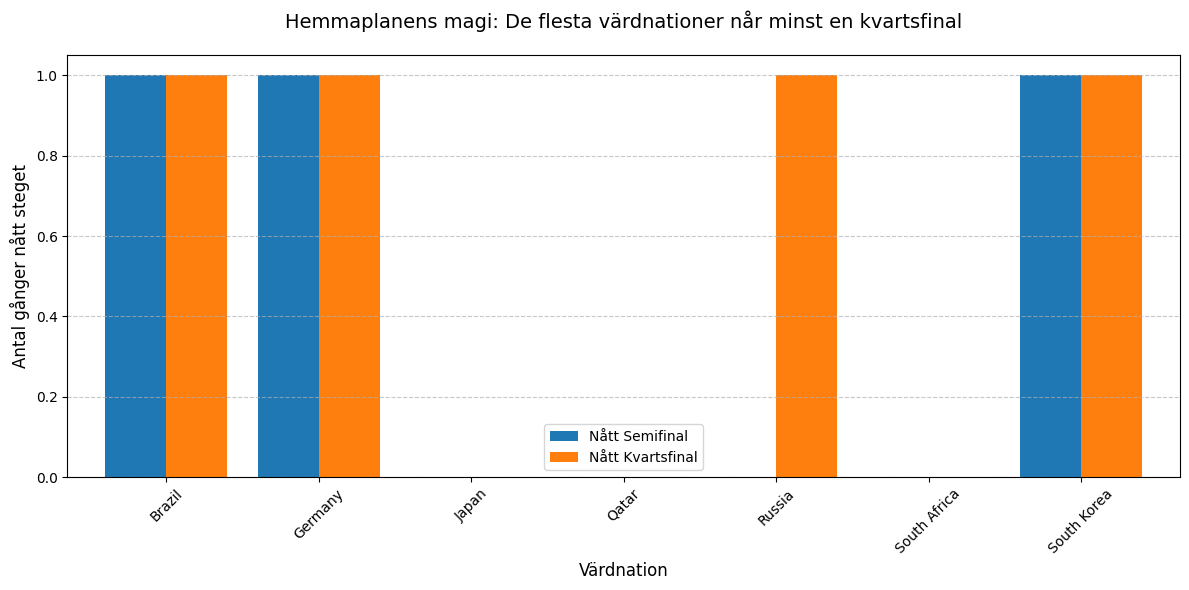

In [60]:
plot_data = host_success[["semi_finalist", "quarter_finalist"]]

ax = plot_data.plot(kind="bar", figsize=(12, 6), width=0.8)


plt.title(
    "Hemmaplanens magi: De flesta värdnationer når minst en kvartsfinal",
    fontsize=14,
    pad=20,
)


plt.xlabel("Värdnation", fontsize=12)
plt.ylabel("Antal gånger nått steget", fontsize=12)
plt.legend(["Nått Semifinal", "Nått Kvartsfinal"])

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Sammanfattningen av datan och diagramen

utifrån att ha sett resan så har jag valt att fokucera på fem olika saker.
- 1. Den ekonomiska dimensionen
- 2. Den mänskliga dimensionen
- 3. Den strukturella dimensionen
- 4. Den statistiska validiteten
- 5. Den historiska dimensionen


#### Den ekonomiska dimensionen:
Om vi börjar med att titta på den första diagrammet som visar vilka landslag som har de dyraste spelarna. 

Där kan vi se att utifrån den data som jag har haft tillgång till är det mestadels europeiska landslag som är med på listan. 
Det är bara de stora lagen brasilien och argentina som är från syd amerika som är med. 

Det som jag tyckte var intressant är att morocco är med på listan. Det kan man tänka på om datan är rätt validerat från början. 
Här kan man också se att spannet mellan det dyraste och den 10::e är 1252.4 - 292.0 = 1160,4 M euro. Det är en stor skillnad tycker jag personligen när man bara ser det. 

Skillnaden mellan första och andra plats är 1452,4 - 1359,2 = 93,2 M euro och det är i mer närbesläktat. 

Man ser det största droppet mellan lagen om man tittar på tredje och fjärde platsen. Där ser man att England har en marknadsvärde på 1268,1 M euro medan Spanien har bara 904,5 M euro. Det är en differens av 363 M euro. Jag tycker personligen att det inte verkar vettigt med det resultatet. Men utifrån den data som är i datasetet så blir resultatet så här. 

#### Den Mänslikliga dimensionen 
Här har jag tyckt det var intressant att kolla på alla spelarna som ska vara med i vm. 

jag har valt att ta ut tre av de i ålder äldsta och yngsta spelarna. 
Samt att det har varit intressant att se var medianen ligger om man tittar på allas åldrar. 

Här har jag fått fram tre spelare med äldst ålder:
- 1. Olivier Giroud 37 år gammal
- 2. Ivan Rakitic 36 år gammal 
- 3. Willian 36 år gammal

Samt de tre spelarna som är yngst:
- 1. Alvin Ayman 16 år gammal
- 2. George Ilenikhena 17 år gammal
- 3. Joane Gadou 17 år gammal 

Här kan man se att den högsta åldern är 37 år gammal. Och att yngsta åldern är 16 år gammal. 
De andra två spelaran på både gammal och ung är i smama ålder med en +- 1. 

jag kan också utläsa att frankrike har den äldsta och yngsta spelaren i deras trupp. 
Samt att europa har flest spelare i detta diagrammet. 

Medan extremerna (16 och 37 år) skapar rubriker, är medianen på 25 år det mest intressanta målet. Det visar att de flesta trupper är byggda kring spelare som befinner sig i sin fysiska 'prime'. Att Frankrike har representanter i båda ändarna av spektrat tyder på en truppstrategi som kombinerar långsiktig återväxt med rutinerat ledarskap. 

#### Den strukturella dimensionen 
Jag ville kunna hänta data och och analysera vilken liga som har flest spelare som är uttagna till landslagen. 

Här kan man se att det är två ligor som ligger på top med totalt 420 spelare. Det är Serie A ( Italien) och Premier League (England)
Det man inte ser i diagrammet eftersom jag har valt att ta bort det är de spelaran som utifrån datan inte har kunnat placeras i en liga. Det har varit mer än de två top ligorna tillsammans med 473 spelare. Det kan man fundera över när man tittar på diagrammet med. Vilken validitet som datan har när man har så många spelare utan liga. 

jag tycker personligen att det var intressant att Championship som är andra ligan i England ligger över både La Liga(Spaninen) och Serie A(Italien). Här kanske man kan börja leta efter kopplingar vilka spelare som spelar var och värde utifrån landslaget. 

MLS är i persinlig mening en farmarliga där många spelare som inte riktigt platsar i andra större ligor spelar. Men spelarna är ändå tillräckligt bra för landslaget och det medför att ligan är med. Fast på 10:e plats

jag har tittat på skillandeln mellan att ha ett diagram liggande eller stående. Det jag känner är att man ser resultatet av antalet spelare lite enklare när staplarana är stående. Men att liga namnen kan sträcka ut sig när stolparna är liggande. 

Jag valde att lägga till ett boxplot diagram i slutet med för att visa hur de lagen i de olika världsdelarna producerar mål. Det kan vara en intressant indikator för det vm som kommer nu. 

Här ser vi att Europa och Sydamrerika har höga median värden som kan visa på att de lagen har en stabil och hög målproduktion. 

Vidare ser vi sprdda resultat som visar på att det är olika i de olika lagens målproduktion. 


#### Den statistiska validiteten
Här ville jag se vilka lag som har vunnit sina matcher men också vad de har för ekenomika muskler alltså hur mycket är spelarna värda och är de värda det. 

Här har jag valt att använda ett scatter diagram för att kunna få en stor overwiev över datan. Samt jag valde att dela in den i olika fält. Vi har Längs uppe till vänst rutan med de lag som har varit effektiva men med ett lag som inte har det högsta marknadsvärdet. Där hittar vi lag från asien, nord amerika och afrika. Men även vissa i europa. De har kunna vinna sina matcher utan att ha de dyraste spelarna. 
Vi har rutan som är under alltså vänster nere. Där ser vi att de flersta lagen ligger. Blandade världsdelar där med. kanske inte samma marknadsvärde på deras lag som i den övre kvadraten. Här är kanske den mer default lagen. Där man har mindre antal vinster med ett lågt marknadsvärde för laget. 

Höger nere är de lag som har har ett marknadsmässtigt starkt lag men som inte har kunnat utbringa det i vinster. Där har vi lag från mestadels Europa. Men även Argentina och Brasilien syns här. 

I den översta högra så är det lag som har en bra vinst svit med spelare som har starkt marknadsvärde.

Scatter-diagrammet bekräftar att högt marknadsvärde ofta korrelerar med vinster (**Frankrike**), men den mest spännande insikten finns i den övre vänstra kvadraten. Att lag med lägre marknadsvärde når hög vinstfrekvens bevisar att taktisk organisation och kollektiv styrka kan utjämna ekonomiska klyftor. Att vissa storklubbar hamnar i rutan för 'Låg ROI' (nere till höger) visar att en dyr trupp utan ett fungerande spelsystem är en riskfylld investering. 

#### en historiska dimensionen
jag tyckte det var intressant att se korrelationen mellan att vara värdland och att kunna gå långt i turneringen. 

När jag såg datan så blev jag lite fundersam eftersom jag inte förväntade mig det resultatet. Och då började jag att verifiera vilken data som jag hade att arbeta med. Då såg jag att jag hade ett spann mellan 2002 - 2024. Detta förklarar varför resultatet ser ut som det gör. 

Här kan man se att Värdlandet bara har gått fram till semifinal. Det är 3 lag av 7 som har gjort detta. 
Det är Brasilien, Tyskland och Sydkorea. Ryssland gick bara till kvarsfinal. 
Här kan man se att det har varit en fördel att kunna ta sig förbi gruppspelet genom att vara värdland. Men att det har varit svårt att gå hela vägen. 
